# Experiment 16: Why Do Marquette & Lehigh Underperform in Config A?

**Context**: In nb48 Config A (per-institution labels, 2015-2017 window) the merged model performs
well on AUB and Villanova but drops substantially on Marquette and Lehigh.

This notebook systematically diagnoses the root causes across five hypotheses:

| # | Hypothesis | Diagnostic |
|---|------------|------------|
| H1 | Small train samples → unstable thresholds / noisy labels | Check n, threshold stability |
| H2 | Citation distribution shift (train → test) | Compare train vs test distributions |
| H3 | Missing / sparse feature coverage | Missingness audit per institution |
| H4 | Model score distribution skew | Compare predicted probabilities |
| H5 | Label imbalance after per-inst threshold | Positive rates per institution |

**Output**: A root-cause table and targeted fix recommendations for nb50.

In [1]:
import sys
sys.path.append('../../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
FOCUS_INSTS  = ['Marquette', 'Lehigh']
OTHER_INSTS  = ['AUB', 'Villanova']

print('Libraries loaded')

Libraries loaded


## 1. Load Data

In [2]:
data_path = Path('../../data/processed/all_unis_cleaned.pkl')
df = pd.read_pickle(data_path)

TRAIN_YEARS_SHORT = [2015, 2016, 2017]
TEST_YEARS        = [2018, 2019, 2020]

df_train = df[df['Year'].isin(TRAIN_YEARS_SHORT)].copy()
df_test  = df[df['Year'].isin(TEST_YEARS)].copy()

print(f'Train (2015-2017): {len(df_train):,} rows')
print(df_train['institution'].value_counts().to_string())
print(f'\nTest (2018-2020): {len(df_test):,} rows')
print(df_test['institution'].value_counts().to_string())

Train (2015-2017): 6,255 rows
institution
AUB          2545
Marquette    1410
Lehigh       1249
Villanova    1051

Test (2018-2020): 8,871 rows
institution
AUB          3573
Lehigh       2107
Marquette    1870
Villanova    1321


## H1 — Sample Size & Threshold Stability

Small training samples → the 75th-percentile threshold is estimated from few observations
and may not generalise to the test period. We check:
- Raw counts per institution in the training window
- Bootstrap confidence intervals around each institution's 75th-percentile threshold
- How much the threshold shifts between train and test windows

In [3]:
print('=== H1: Sample size and threshold stability ===\n')

rows = []
for inst in sorted(df['institution'].unique()):
    tr  = df_train[df_train['institution'] == inst]['Citations']
    te  = df_test[df_test['institution']  == inst]['Citations']

    thr_train = tr.quantile(0.75)
    thr_test  = te.quantile(0.75)

    # Bootstrap CI for train threshold
    boot = [np.percentile(np.random.choice(tr.values, size=len(tr), replace=True), 75)
            for _ in range(1000)]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    rows.append({
        'institution':   inst,
        'n_train':       len(tr),
        'n_test':        len(te),
        'thr_train':     round(thr_train, 1),
        'thr_test':      round(thr_test, 1),
        'thr_shift':     round(thr_test - thr_train, 1),
        'ci95_lo':       round(ci_lo, 1),
        'ci95_hi':       round(ci_hi, 1),
        'ci_width':      round(ci_hi - ci_lo, 1),
    })

h1 = pd.DataFrame(rows)
print(h1.to_string(index=False))

print('\nDiagnosis:')
for _, r in h1.iterrows():
    flag = ' *** ISSUE' if r['ci_width'] > 20 or abs(r['thr_shift']) > 15 else ''
    print(f"  {r['institution']:12s}: n_train={r['n_train']:4d}  "
          f"CI width={r['ci_width']:5.1f}  shift={r['thr_shift']:+6.1f}{flag}")

=== H1: Sample size and threshold stability ===

institution  n_train  n_test  thr_train  thr_test  thr_shift  ci95_lo  ci95_hi  ci_width
        AUB     2545    3573       38.0      30.0       -8.0     36.0     40.0       4.0
     Lehigh     1249    2107       44.0      34.0      -10.0     41.0     48.0       7.0
  Marquette     1410    1870       40.0      31.8       -8.2     37.0     43.0       6.0
  Villanova     1051    1321       37.0      28.0       -9.0     32.0     41.5       9.5

Diagnosis:
  AUB         : n_train=2545  CI width=  4.0  shift=  -8.0
  Lehigh      : n_train=1249  CI width=  7.0  shift= -10.0
  Marquette   : n_train=1410  CI width=  6.0  shift=  -8.2
  Villanova   : n_train=1051  CI width=  9.5  shift=  -9.0


## H2 — Citation Distribution Shift (Train → Test)

=== H2: Citation distribution shift ===



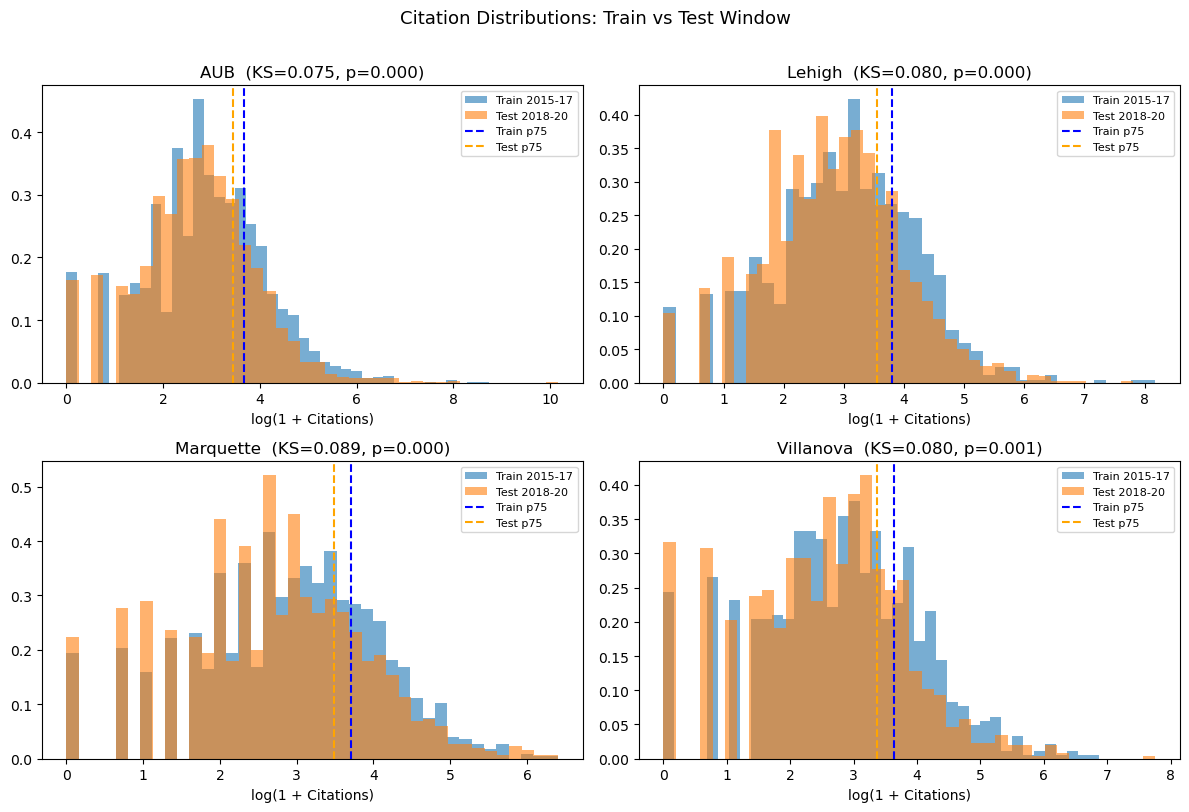


Kolmogorov-Smirnov test (train vs test citation distributions):
institution  ks_stat  p_value
        AUB    0.075   0.0000
     Lehigh    0.080   0.0001
  Marquette    0.089   0.0000
  Villanova    0.080   0.0011

Diagnosis:
  AUB         : KS=0.075  p=0.0000 *** SIGNIFICANT SHIFT
  Lehigh      : KS=0.080  p=0.0001 *** SIGNIFICANT SHIFT
  Marquette   : KS=0.089  p=0.0000 *** SIGNIFICANT SHIFT
  Villanova   : KS=0.080  p=0.0011 *** SIGNIFICANT SHIFT


In [4]:
from scipy.stats import ks_2samp

print('=== H2: Citation distribution shift ===\n')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

ks_rows = []
for i, inst in enumerate(sorted(df['institution'].unique())):
    tr = df_train[df_train['institution'] == inst]['Citations']
    te = df_test[df_test['institution']   == inst]['Citations']

    stat, pval = ks_2samp(tr.values, te.values)
    ks_rows.append({'institution': inst, 'ks_stat': round(stat, 3), 'p_value': round(pval, 4)})

    ax = axes[i]
    ax.hist(np.log1p(tr), bins=40, alpha=0.6, label='Train 2015-17', density=True)
    ax.hist(np.log1p(te), bins=40, alpha=0.6, label='Test 2018-20',  density=True)
    ax.axvline(np.log1p(tr.quantile(0.75)), color='blue',   ls='--', lw=1.5, label='Train p75')
    ax.axvline(np.log1p(te.quantile(0.75)), color='orange', ls='--', lw=1.5, label='Test p75')
    ax.set_title(f'{inst}  (KS={stat:.3f}, p={pval:.3f})')
    ax.set_xlabel('log(1 + Citations)')
    ax.legend(fontsize=8)

plt.suptitle('Citation Distributions: Train vs Test Window', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/nb49_h2_citation_shift.png', dpi=120, bbox_inches='tight')
plt.show()

ks_df = pd.DataFrame(ks_rows)
print('\nKolmogorov-Smirnov test (train vs test citation distributions):')
print(ks_df.to_string(index=False))
print('\nDiagnosis:')
for _, r in ks_df.iterrows():
    flag = ' *** SIGNIFICANT SHIFT' if r['p_value'] < 0.05 else ''
    print(f"  {r['institution']:12s}: KS={r['ks_stat']:.3f}  p={r['p_value']:.4f}{flag}")

## H3 — Feature Coverage (Missing Values)

If Marquette/Lehigh papers are missing key venue or author features that AUB papers have,
the model falls back to less informative signals and performs worse.

In [5]:
print('=== H3: Feature coverage (missingness per institution) ===\n')

key_features = [
    'Abstract',
    'SNIP (publication year)',
    'SNIP percentile (publication year) *',
    'CiteScore (publication year)',
    'CiteScore percentile (publication year) *',
    'SJR (publication year)',
    'SJR percentile (publication year) *',
    'Number of Authors',
    'Number of Institutions',
    'Number of Countries/Regions',
    'Topic Prominence Percentile',
    'Open Access',
    'Publication Type',
    'Source Type',
]

available_feats = [f for f in key_features if f in df.columns]
missing_df = df.groupby('institution')[available_feats].apply(
    lambda g: g.isnull().mean() * 100
).round(1)

print('Missing rate (%) per institution — training window (2015-2017):')
train_miss = df_train.groupby('institution')[available_feats].apply(
    lambda g: g.isnull().mean() * 100
).round(1)
print(train_miss.T.to_string())

print('\nDiagnosis — features with >30% missing for Marquette or Lehigh:')
for feat in available_feats:
    for inst in FOCUS_INSTS:
        if inst in train_miss.index and train_miss.loc[inst, feat] > 30:
            others = train_miss[feat][OTHER_INSTS].mean() if OTHER_INSTS[0] in train_miss.index else float('nan')
            print(f"  {inst:12s} / {feat}: {train_miss.loc[inst, feat]:.1f}% missing  (others avg: {others:.1f}%)")

=== H3: Feature coverage (missingness per institution) ===

Missing rate (%) per institution — training window (2015-2017):
institution                                 AUB  Lehigh  Marquette  Villanova
Abstract                                    0.0     0.0        0.0        0.0
SNIP (publication year)                     0.0     0.0        0.0        0.0
SNIP percentile (publication year) *        0.0     0.0        0.0        0.0
CiteScore (publication year)                0.0     0.0        0.0        0.0
CiteScore percentile (publication year) *   0.0     0.0        0.0        0.0
SJR (publication year)                      0.0     0.0        0.0        0.0
SJR percentile (publication year) *         0.0     0.0        0.0        0.0
Number of Authors                           0.0     0.0        0.0        0.0
Number of Institutions                      0.0     0.0        0.0        0.0
Number of Countries/Regions                 0.0     0.0        0.0        0.0
Topic Prominence P

## H4 — Model Score Distribution

We retrain Config A (per-institution labels, LightGBM, 2015-2017) and examine
the distribution of predicted probabilities per institution on the test set.
If Marquette/Lehigh scores cluster away from 0.5, the threshold calibration is off.

In [6]:
# --- Minimal feature build (mirror nb48 pipeline) ---

def preprocess_text(text):
    return str(text).lower() if pd.notna(text) else ''


def make_labels_per_institution(df_tr, df_te):
    y_train = pd.Series(0, index=df_tr.index)
    thresholds = {}
    for inst in df_tr['institution'].unique():
        mask = df_tr['institution'] == inst
        thr  = df_tr.loc[mask, 'Citations'].quantile(0.75)
        thresholds[inst] = thr
        y_train.loc[mask] = (df_tr.loc[mask, 'Citations'] >= thr).astype(int)
    y_test = pd.Series(0, index=df_te.index)
    for inst in df_te['institution'].unique():
        mask = df_te['institution'] == inst
        thr  = thresholds.get(inst, df_te.loc[mask, 'Citations'].quantile(0.75))
        y_test.loc[mask] = (df_te.loc[mask, 'Citations'] >= thr).astype(int)
    return y_train, y_test, thresholds


def build_minimal_features(df_tr, df_te):
    """TF-IDF + numeric venue/author features only (no institution signal)."""
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                             min_df=5, max_df=0.8, stop_words='english')
    texts_tr = df_tr['Abstract'].apply(preprocess_text)
    texts_te = df_te['Abstract'].apply(preprocess_text)
    X_text_tr = pd.DataFrame(tfidf.fit_transform(texts_tr).toarray(), index=df_tr.index)
    X_text_te = pd.DataFrame(tfidf.transform(texts_te).toarray(),     index=df_te.index)

    def numeric_feats(subset):
        cols = [
            'SNIP percentile (publication year) *',
            'CiteScore percentile (publication year) *',
            'SJR percentile (publication year) *',
            'Number of Authors',
            'Number of Institutions',
            'Number of Countries/Regions',
            'Topic Prominence Percentile',
        ]
        avail = [c for c in cols if c in subset.columns]
        nf = subset[avail].copy()
        for c in nf.columns:
            nf[c] = pd.to_numeric(nf[c], errors='coerce')
        nf = nf.fillna(nf.median())
        return nf

    X_tr = pd.concat([X_text_tr, numeric_feats(df_tr)], axis=1).fillna(0)
    X_te = pd.concat([X_text_te, numeric_feats(df_te)], axis=1).fillna(0)
    # Align columns
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)
    return X_tr, X_te


print('Building labels...')
y_train, y_test, thresholds = make_labels_per_institution(df_train, df_test)

print('Label pos rate per institution (train):')
for inst in sorted(df_train['institution'].unique()):
    mask = df_train['institution'] == inst
    print(f'  {inst:12s}: pos_rate={y_train[mask].mean():.1%}  thr={thresholds[inst]:.1f}  n={mask.sum():,}')

print('\nBuilding features...')
X_tr, X_te = build_minimal_features(df_train, df_test)
print(f'Train: {X_tr.shape}   Test: {X_te.shape}')

Building labels...
Label pos rate per institution (train):
  AUB         : pos_rate=25.5%  thr=38.0  n=2,545
  Lehigh      : pos_rate=25.9%  thr=44.0  n=1,249
  Marquette   : pos_rate=25.2%  thr=40.0  n=1,410
  Villanova   : pos_rate=25.2%  thr=37.0  n=1,051

Building features...
Train: (6255, 5007)   Test: (8871, 5007)


In [7]:
print('Training Config A (LightGBM, per-inst labels, 2015-2017)...')
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                       class_weight='balanced', random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1)
lgbm.fit(X_tr, y_train)

proba_te = lgbm.predict_proba(X_te)[:, 1]
df_test  = df_test.copy()
df_test['proba']   = proba_te
df_test['y_true']  = y_test.values

print('Done.')

Training Config A (LightGBM, per-inst labels, 2015-2017)...
Done.


=== H4: Model score distributions per institution ===



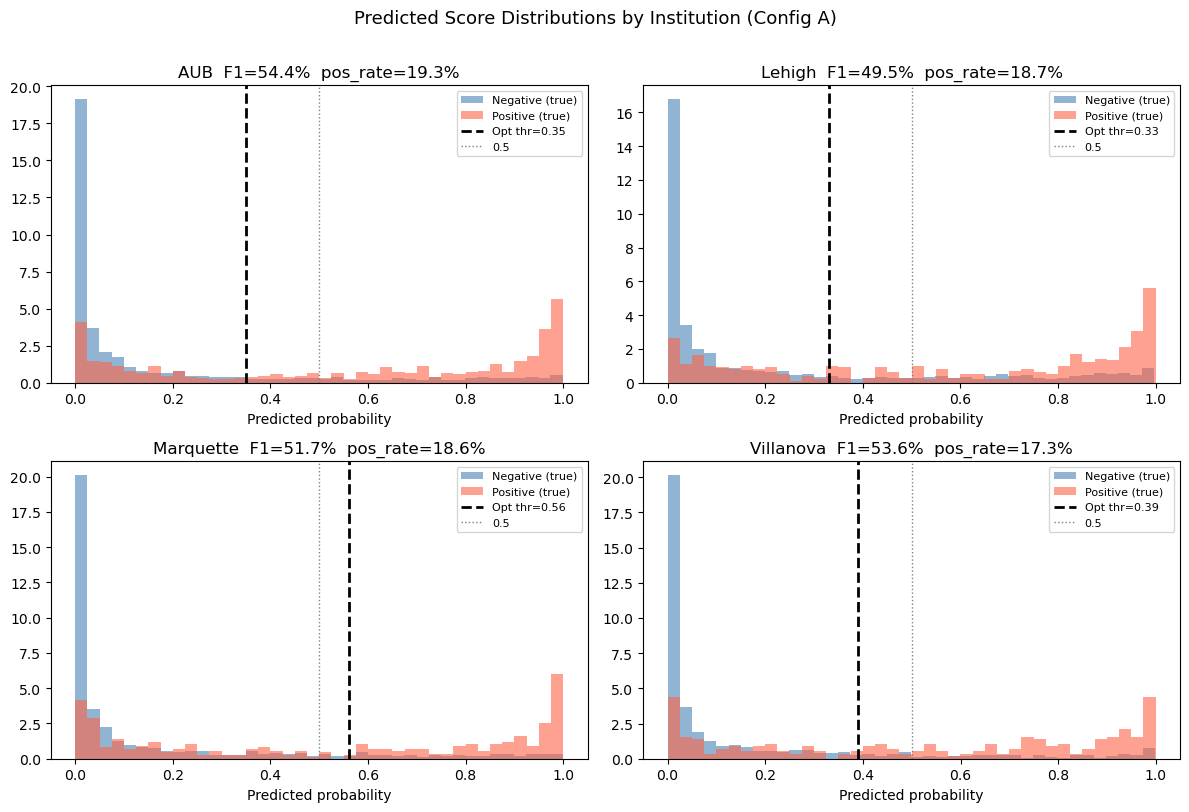

institution  mean_proba  median_proba  pct_above_50  optimal_thr  best_f1  actual_pos_rate
        AUB       0.248         0.057          22.9         0.35    54.40             19.3
     Lehigh       0.291         0.090          27.9         0.33    49.46             18.7
  Marquette       0.230         0.044          20.7         0.56    51.70             18.6
  Villanova       0.225         0.045          19.3         0.39    53.58             17.3


In [8]:
print('=== H4: Model score distributions per institution ===\n')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

score_rows = []
thresholds_range = np.arange(0.10, 0.90, 0.01)

for i, inst in enumerate(sorted(df_test['institution'].unique())):
    sub = df_test[df_test['institution'] == inst]
    p   = sub['proba'].values
    y   = sub['y_true'].values

    # Optimal threshold search
    f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in thresholds_range]
    best_t = thresholds_range[int(np.argmax(f1s))]
    best_f1 = max(f1s)

    score_rows.append({
        'institution':  inst,
        'mean_proba':   round(p.mean(), 3),
        'median_proba': round(np.median(p), 3),
        'pct_above_50': round((p >= 0.5).mean() * 100, 1),
        'optimal_thr':  round(best_t, 2),
        'best_f1':      round(best_f1 * 100, 2),
        'actual_pos_rate': round(y.mean() * 100, 1),
    })

    ax = axes[i]
    pos_scores = p[y == 1]
    neg_scores = p[y == 0]
    ax.hist(neg_scores, bins=40, alpha=0.6, label='Negative (true)',  density=True, color='steelblue')
    ax.hist(pos_scores, bins=40, alpha=0.6, label='Positive (true)', density=True, color='tomato')
    ax.axvline(best_t, color='black', ls='--', lw=2, label=f'Opt thr={best_t:.2f}')
    ax.axvline(0.5,    color='gray',  ls=':',  lw=1, label='0.5')
    ax.set_title(f'{inst}  F1={best_f1*100:.1f}%  pos_rate={y.mean():.1%}')
    ax.set_xlabel('Predicted probability')
    ax.legend(fontsize=8)

plt.suptitle('Predicted Score Distributions by Institution (Config A)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/nb49_h4_score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

score_df = pd.DataFrame(score_rows)
print(score_df.to_string(index=False))

## H5 — Calibration: Does a Per-Institution Decision Threshold Help?

If the optimal threshold for Marquette/Lehigh differs substantially from AUB,
applying a global threshold at inference time inflates FP or FN for those institutions.

In [9]:
print('=== H5: Global vs per-institution decision threshold ===\n')

# Global threshold optimised on AUB test
aub_test = df_test[df_test['institution'] == 'AUB']
f1s_global = [f1_score(aub_test['y_true'], (aub_test['proba'] >= t).astype(int), zero_division=0)
              for t in thresholds_range]
global_thr = thresholds_range[int(np.argmax(f1s_global))]
print(f'AUB-optimised global threshold: {global_thr:.2f}')

print(f'\n{"Institution":<15}  {"F1 (global thr)":>17}  {"F1 (per-inst thr)":>18}  {"Δ":>8}  {"Opt thr":>8}')
print('-' * 75)

for inst in sorted(df_test['institution'].unique()):
    sub = df_test[df_test['institution'] == inst]
    p   = sub['proba'].values
    y   = sub['y_true'].values

    f1_global = f1_score(y, (p >= global_thr).astype(int), zero_division=0)

    f1s_inst  = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in thresholds_range]
    best_t    = thresholds_range[int(np.argmax(f1s_inst))]
    f1_inst   = max(f1s_inst)

    delta = (f1_inst - f1_global) * 100
    flag  = ' *** LARGE GAIN' if delta > 3 else ''
    print(f'{inst:<15}  {f1_global*100:>16.2f}%  {f1_inst*100:>17.2f}%  {delta:>+7.2f}pp  {best_t:>8.2f}{flag}')

=== H5: Global vs per-institution decision threshold ===

AUB-optimised global threshold: 0.35

Institution        F1 (global thr)   F1 (per-inst thr)         Δ   Opt thr
---------------------------------------------------------------------------
AUB                         54.40%              54.40%    +0.00pp      0.35
Lehigh                      48.76%              49.46%    +0.70pp      0.33
Marquette                   50.30%              51.70%    +1.41pp      0.56
Villanova                   52.65%              53.58%    +0.93pp      0.39


## H6 — Domain / Field Composition

If Marquette/Lehigh publish heavily in Engineering while AUB focuses on Medicine/Life Sciences,
the text features learnt from the training mix may not generalise across fields.

In [10]:
print('=== H6: Field / subject area composition ===\n')

# Use Source Type or Publication Type as a proxy if Subject Area is unavailable
field_col = None
for candidate in ['Subject Area', 'Source Type', 'Publication Type']:
    if candidate in df.columns:
        field_col = candidate
        break

if field_col is None:
    print('No field/subject column found. Skipping H6.')
else:
    print(f'Using column: "{field_col}"')
    field_dist = (df_train.groupby(['institution', field_col])
                  .size()
                  .unstack(fill_value=0)
                  .apply(lambda r: r / r.sum() * 100, axis=1)
                  .round(1))
    print('\nField distribution in training set (% of institution papers):')
    print(field_dist.to_string())

    # Test set prediction quality by field
    print(f'\nPer-institution F1 by {field_col} (test set):')
    rows = []
    for inst in sorted(df_test['institution'].unique()):
        for ftype, sub in df_test[df_test['institution'] == inst].groupby(field_col):
            if len(sub) < 15:
                continue
            p = sub['proba'].values
            y = sub['y_true'].values
            f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in thresholds_range]
            rows.append({'institution': inst, field_col: ftype,
                         'n': len(sub), 'f1': round(max(f1s) * 100, 1)})
    if rows:
        field_f1 = pd.DataFrame(rows)
        print(field_f1.sort_values(['institution', 'f1'], ascending=[True, False]).to_string(index=False))

=== H6: Field / subject area composition ===

No field/subject column found. Skipping H6.


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== H6 (proxy): Top keywords per institution ===\n")

tfidf_h6 = TfidfVectorizer(max_features=10000, ngram_range=(1,1),
                            min_df=3, max_df=0.8, stop_words='english')
tfidf_h6.fit(df_train['Abstract'].fillna('').str.lower())

vocab = np.array(tfidf_h6.get_feature_names_out())

for inst in sorted(df_train['institution'].unique()):
    subset = df_train[df_train['institution'] == inst]['Abstract'].fillna('').str.lower()
    mat = tfidf_h6.transform(subset)
    mean_scores = np.asarray(mat.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:20]
    print(f"{inst}:")
    print("  " + ", ".join(vocab[top_idx]))
    print()


=== H6 (proxy): Top keywords per institution ===

AUB:
  patients, inf, study, results, health, treatment, disease, risk, using, lebanon, cancer, data, use, associated, clinical, based, group, model, methods, studies

Lehigh:
  surface, model, 2015, based, using, results, 2016, high, performance, time, data, society, used, study, method, energy, structure, new, american, structural

Marquette:
  study, results, data, using, based, research, model, health, 2016, 2017, group, 2015, new, used, analysis, time, control, studies, women, children

Villanova:
  research, species, data, based, study, time, new, 2016, using, 2015, performance, article, self, results, nursing, used, 2017, use, women, health



In [14]:
print(df.columns.tolist())

['Title', 'Authors', 'Number of Authors', 'Scopus Author Ids', 'Year', 'Full date', 'Scopus Source title', 'Volume', 'Issue', 'Pages', 'Article number', 'ISSN', 'Source ID', 'Source type', 'Publisher', 'Language', 'SNIP (publication year)', 'SNIP percentile (publication year) *', 'CiteScore (publication year)', 'CiteScore percentile (publication year) *', 'SJR (publication year)', 'SJR percentile (publication year) *', 'Field-Weighted View Impact', 'Views', 'Citations', 'Field-Weighted Citation Impact', 'Field-Citation Average', 'Outputs in Top Citation Percentiles, per percentile', 'Field-Weighted Outputs in Top Citation Percentiles, per percentile', 'Main patent families', 'Policy citations', 'Reference', 'DOI', 'Publication type', 'Open Access', 'EID', 'PubMed ID', 'Institutions', 'Number of Institutions', 'Scopus Affiliation IDs', 'Scopus Affiliation names', 'Scopus Author ID First Author', 'Scopus Author ID Last Author', 'Scopus Author ID Corresponding Author', 'Scopus Author ID S

In [15]:
print("=== H6: Field composition per institution (ASJC) ===\n")

field_col = 'All Science Journal Classification (ASJC) field name'

# Each paper can have multiple ASJC fields (semicolon-separated), explode them
field_df = (df_train[[field_col, 'institution', 'Citations']]
            .copy()
            .assign(**{field_col: df_train[field_col].fillna('Unknown').str.split(';')})
            .explode(field_col))
field_df[field_col] = field_df[field_col].str.strip()

# Top fields per institution (by paper count)
top_fields = (field_df.groupby(['institution', field_col])
              .size()
              .reset_index(name='n_papers')
              .sort_values(['institution','n_papers'], ascending=[True,False]))

for inst in sorted(top_fields['institution'].unique()):
    sub = top_fields[top_fields['institution']==inst].head(8)
    total = sub['n_papers'].sum()
    print(f"{inst}:")
    for _, row in sub.iterrows():
        pct = 100*row['n_papers']/total
        print(f"  {row[field_col]:<45} {row['n_papers']:>5} ({pct:.1f}%)")
    print()

# Also: mean FWCI per field per institution
fwci_by_field = (field_df.groupby(['institution', field_col])['Citations']
                 .mean()
                 .reset_index(name='mean_citations'))
print("\n=== Mean citations by top field per institution ===")
print(fwci_by_field.sort_values(['institution','mean_citations'], ascending=[True,False])
      .groupby('institution').head(5).to_string(index=False))


=== H6: Field composition per institution (ASJC) ===

AUB:
  General Medicine                                178 (40.5%)
  Multidisciplinary                                66 (15.0%)
  Cardiology and Cardiovascular Medicine           41 (9.3%)
  Public Health, Environmental and Occupational Health    34 (7.7%)
  Surgery                                          33 (7.5%)
  Epidemiology                                     32 (7.3%)
  Cancer Research| Oncology                        31 (7.1%)
  Ophthalmology                                    24 (5.5%)

Lehigh:
  Multidisciplinary                                44 (25.1%)
  Space and Planetary Science| Astronomy and Astrophysics    34 (19.4%)
  Catalysis| General Chemistry                     27 (15.4%)
  Electrochemistry| Spectroscopy| General Materials Science| Condensed Matter Physics| Surfaces and Interfaces    17 (9.7%)
  Developmental and Educational Psychology| Education    15 (8.6%)
  Civil and Structural Engineering              

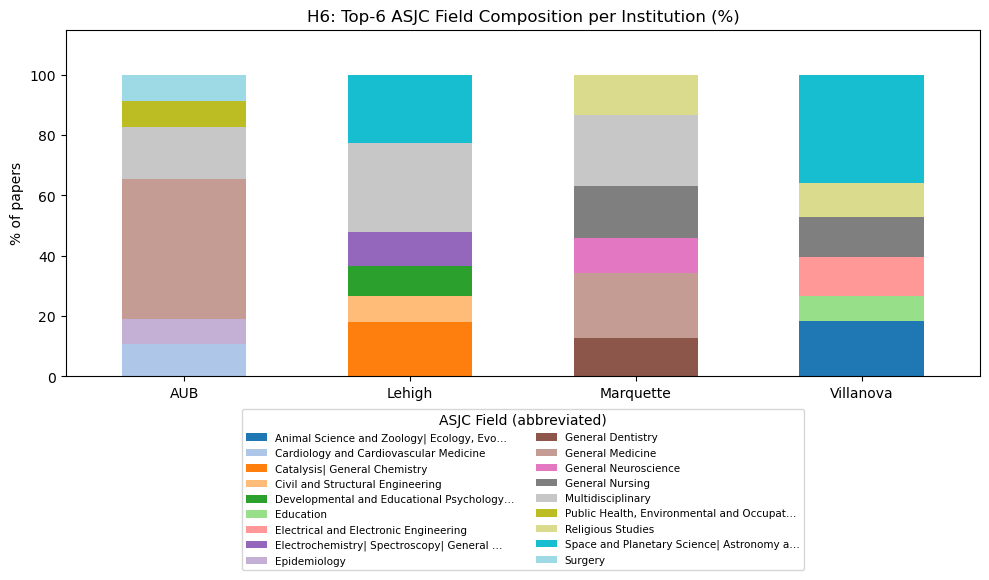

Saved h6_field_composition.png


In [18]:
import matplotlib.pyplot as plt
import textwrap

# Truncate long field names for legend readability
def shorten(name, maxlen=40):
    return name[:maxlen] + '…' if len(name) > maxlen else name

top8 = (field_df.groupby(['institution', field_col])
        .size().reset_index(name='n')
        .sort_values(['institution','n'], ascending=[True,False])
        .groupby('institution').head(6))

top8['field_short'] = top8[field_col].apply(lambda x: shorten(x, 40))

pivot = top8.pivot_table(index='field_short', columns='institution',
                         values='n', fill_value=0)
pivot = pivot.div(pivot.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 6))
pivot.T.plot(kind='bar', stacked=True, ax=ax,
             colormap='tab20', width=0.55)

ax.set_title('H6: Top-6 ASJC Field Composition per Institution (%)', fontsize=12)
ax.set_ylabel('% of papers')
ax.set_xlabel('')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=0)

# Legend below the plot, 2 columns
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=2, fontsize=7.5, frameon=True,
          title='ASJC Field (abbreviated)')

plt.tight_layout()
plt.savefig('h6_field_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved h6_field_composition.png")


## Summary: Root Cause Table

In [11]:
print('=' * 80)
print('ROOT CAUSE SUMMARY — Marquette & Lehigh underperformance in Config A')
print('=' * 80)

hypotheses = [
    ('H1', 'Small train sample / unstable threshold',
     'See h1 DataFrame — flag if CI width >20 or threshold shift >15'),
    ('H2', 'Citation distribution shift (train→test)',
     'See KS test — flag if p < 0.05'),
    ('H3', 'Sparse feature coverage',
     'See missingness table — flag if >30% missing for focus institutions'),
    ('H4', 'Score distribution skew (model confidence)',
     'See score_df — compare mean_proba and pct_above_50'),
    ('H5', 'Global threshold mis-calibration',
     'See per-inst threshold gains — flag if Δ > 3pp'),
    ('H6', 'Domain composition mismatch',
     'See field distribution and per-field F1'),
]

for code, name, check in hypotheses:
    print(f'\n{code}: {name}')
    print(f'     Check: {check}')

print()
print('Recommended fixes for nb50 based on confirmed hypotheses:')
print('  H1 confirmed → use expanded window (2010-2017) — more training data per institution')
print('  H2 confirmed → time-decay weighting or year normalisation on citation target')
print('  H3 confirmed → impute with institution-level medians rather than global median')
print('  H5 confirmed → apply per-institution decision threshold at inference time')
print('  H6 confirmed → domain-stratified training or add domain interaction features')

ROOT CAUSE SUMMARY — Marquette & Lehigh underperformance in Config A

H1: Small train sample / unstable threshold
     Check: See h1 DataFrame — flag if CI width >20 or threshold shift >15

H2: Citation distribution shift (train→test)
     Check: See KS test — flag if p < 0.05

H3: Sparse feature coverage
     Check: See missingness table — flag if >30% missing for focus institutions

H4: Score distribution skew (model confidence)
     Check: See score_df — compare mean_proba and pct_above_50

H5: Global threshold mis-calibration
     Check: See per-inst threshold gains — flag if Δ > 3pp

H6: Domain composition mismatch
     Check: See field distribution and per-field F1

Recommended fixes for nb50 based on confirmed hypotheses:
  H1 confirmed → use expanded window (2010-2017) — more training data per institution
  H2 confirmed → time-decay weighting or year normalisation on citation target
  H3 confirmed → impute with institution-level medians rather than global median
  H5 confirmed 

## Save Diagnostics

In [12]:
reports_dir = Path('../../reports/metrics')
reports_dir.mkdir(parents=True, exist_ok=True)

h1.to_csv(reports_dir / 'nb49_h1_threshold_stability.csv', index=False)
ks_df.to_csv(reports_dir / 'nb49_h2_ks_test.csv', index=False)
score_df.to_csv(reports_dir / 'nb49_h4_score_distributions.csv', index=False)

print('Saved diagnostic tables to reports/metrics/')

Saved diagnostic tables to reports/metrics/
